<a href="https://colab.research.google.com/github/l21141336-glitch/Analisis-y-visualizacion-de-datos/blob/main/Laura_Andrea_Alvarez_Nicasio_14_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
install.packages("devtools")
#devtools::install_github("r-lib/conflicted")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘fs’


Warning message in install.packages("devtools"):
“installation of package ‘fs’ had non-zero exit status”
Warning message in install.packages("devtools"):
“installation of package ‘devtools’ had non-zero exit status”


In [54]:
library(dplyr)
library (conflicted)
conflicts_prefer(dplyr::filter)

[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::filter over any other package.


In [55]:
## Instala los paquetes si no los tienes:
 install.packages(c("tidyverse", "lubridate", "writexl","scales",
"DBI"))
library(tidyverse)
library(lubridate)
library(scales)
library(writexl)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [56]:
# 1. Cargar librerías necesarias
library(tidyverse)
library(lubridate)

# 1. EXTRACT: Generar dataset con errores intencionales
set.seed(42)
n <- 500

# Creamos una secuencia de fechas base
fechas_base <- seq(as.Date("2024-01-01"), as.Date("2024-12-31"), by="day")

ventas_raw <- tibble(
  id_venta = 1:n,

  # Corrección de fecha: Generamos fechas aleatorias y luego aplicamos formatos mixtos
  fecha_venta = sample(c(
    format(sample(fechas_base, n/2, replace=TRUE), "%d/%m/%Y"),
    format(sample(fechas_base, n/2, replace=TRUE), "%Y-%m-%d"),
    NA_character_
  ), n, replace=TRUE),

  id_producto = sample(paste0('P', sprintf("%03d", 1:30)), n, replace=TRUE),

  producto = sample(c("Laptop","LAPTOP","laptop",
                      "Silla","SILLA",
                      "Playera","playera",
                      "Cereal", "CEREAL",
                      "Televisor","televisor"), n, replace=TRUE),

  categoria = sample(c("Electrónico", "Hogar", "Ropa","Alimento", NA_character_), n,
                     replace=TRUE, prob=c(.25,.25,.2,.2,.1)),

  region = sample(c("Norte","Sur","Centro",
                    "Occidente","Oriente"), n, replace=TRUE),

  vendedor = sample(c("Ana López","ana lopez","ANA LOPEZ",
                      "Carlos Ruiz","carlos ruiz",
                      "María Torres", "Javier Soto"), n, replace=TRUE),

  cantidad = sample(c(1:50, -5, -10, 0), n, replace=TRUE),

  # Se mantiene como caracter para simular suciedad de datos (mezcla de números y $)
  precio_unitario = sample(c("100", "250", "500", "1200", "3500", "8000",
                             "$1500","$250", NA_character_), n, replace=TRUE),

  descuento_pct = sample(c(0, 5, 10, 15, 20, 25, 30, NA_real_), n, replace=TRUE),

  canal_venta = sample(c("Online","Tienda","Distribuidor", NA_character_), n, replace=TRUE)
)

# Visualizar las primeras filas
print(head(ventas_raw))

# A tibble: 6 × 11
  id_venta fecha_venta id_producto producto categoria   region vendedor cantidad
     <int> <chr>       <chr>       <chr>    <chr>       <chr>  <chr>       <dbl>
1        1 25/10/2024  P002        Laptop   Hogar       Occid… Ana Lóp…       29
2        2 2024-01-10  P016        Silla    NA          Centro ANA LOP…       12
3        3 2024-03-07  P030        Laptop   Electrónico Norte  Carlos …       23
4        4 21/04/2024  P025        Laptop   Electrónico Occid… Javier …       15
5        5 2024-01-15  P030        Laptop   NA          Centro María T…       26
6        6 2024-07-31  P009        Laptop   Ropa        Sur    Carlos …       50
# ℹ 3 more variables: precio_unitario <chr>, descuento_pct <dbl>,
#   canal_venta <chr>


In [57]:

library(tidyverse)

# ── 1.2 Diagnóstico inicial (Profile) ─────────────────────────
glimpse(ventas_raw)
summary(ventas_raw)

# Conteo de valores nulos por columna (Versión corregida y limpia)
ventas_raw %>%
  summarise(across(everything(), ~sum(is.na(.x)))) %>%
  pivot_longer(cols = everything(), names_to = "columna", values_to = "nulos") %>%
  arrange(desc(nulos)) %>%
  print()

Rows: 500
Columns: 11
$ id_venta        <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ fecha_venta     <chr> "25/10/2024", "2024-01-10", "2024-03-07", "21/04/2024"…
$ id_producto     <chr> "P002", "P016", "P030", "P025", "P030", "P009", "P005"…
$ producto        <chr> "Laptop", "Silla", "Laptop", "Laptop", "Laptop", "Lapt…
$ categoria       <chr> "Hogar", NA, "Electrónico", "Electrónico", NA, "Ropa",…
$ region          <chr> "Occidente", "Centro", "Norte", "Occidente", "Centro",…
$ vendedor        <chr> "Ana López", "ANA LOPEZ", "Carlos Ruiz", "Javier Soto"…
$ cantidad        <dbl> 29, 12, 23, 15, 26, 50, 18, 29, 12, 26, 28, 18, 33, -5…
$ precio_unitario <chr> "500", "$250", "$1500", "$250", "8000", NA, "$1500", "…
$ descuento_pct   <dbl> 25, 10, 0, 25, 0, 15, NA, 5, 15, 15, 5, 30, NA, 20, 25…
$ canal_venta     <chr> "Tienda", "Tienda", "Tienda", "Tienda", "Tienda", "Tie…


    id_venta     fecha_venta        id_producto          producto        
 Min.   :  1.0   Length:500         Length:500         Length:500        
 1st Qu.:125.8   Class :character   Class :character   Class :character  
 Median :250.5   Mode  :character   Mode  :character   Mode  :character  
 Mean   :250.5                                                           
 3rd Qu.:375.2                                                           
 Max.   :500.0                                                           
                                                                         
  categoria            region            vendedor            cantidad     
 Length:500         Length:500         Length:500         Min.   :-10.00  
 Class :character   Class :character   Class :character   1st Qu.: 12.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 25.50  
                                                          Mean   : 24.72  
                                 

# A tibble: 11 × 2
   columna         nulos
   <chr>           <int>
 1 canal_venta       120
 2 descuento_pct      66
 3 precio_unitario    54
 4 categoria          45
 5 id_venta            0
 6 fecha_venta         0
 7 id_producto         0
 8 producto            0
 9 region              0
10 vendedor            0
11 cantidad            0


LIMPIEZA DE CODIGO

In [58]:

# ── SECCIÓN II: LIMPIEZA Y TRANSFORMACIÓN ────────────────────────────
library(lubridate)
library(stringr)

ventas_limpio <- ventas_raw %>%
  ## ── 2.1 Corregir fechas con formatos mixtos ──────────────────────
  mutate(fecha_venta = parse_date_time(fecha_venta,
                                       orders = c("dmy", "ymd"),
                                       quiet = TRUE) %>% as.Date()) %>%

  ## ── 2.2 Convertir precio_unitario a numérico ─────────────────────
  mutate(precio_unitario = as.numeric(str_remove(precio_unitario, "\\$"))) %>%

  ## ── 2.3 Eliminar registros con cantidad <= 0 ─────────────────────
  filter(cantidad > 0) %>%

  ## ── 2.4 Estandarizar texto (mayúsculas iniciales) ────────────────
  mutate(
    producto = str_to_title(producto),
    vendedor = str_to_title(vendedor),
    categoria = str_to_title(categoria)
  ) %>%

  ## ── 2.5 Imputar valores faltantes ────────────────────────────────
  mutate(
    categoria = replace_na(categoria, "Sin Categoría"),
    canal_venta = replace_na(canal_venta, "Desconocido"),
    descuento_pct = replace_na(descuento_pct, 0)
  ) %>%

  ## ── 2.6 Crear columnas calculadas ────────────────────────────────
  mutate(
    venta_bruta = cantidad * precio_unitario,
    descuento_monto = venta_bruta * (descuento_pct / 100),
    venta_neta = venta_bruta - descuento_monto,
    mes = month(fecha_venta, label = TRUE, abbr = FALSE),
    trimestre = paste0("Q", quarter(fecha_venta)),
    anio = year(fecha_venta)
  ) %>%

  ## ── 2.7 Eliminar duplicados exactos ──────────────────────────────
  distinct()

# Mensaje de confirmación en consola
cat("✅ TRANSFORM completado:", nrow(ventas_limpio), "registros válidos\n")
cat("Registros eliminados:", nrow(ventas_raw) - nrow(ventas_limpio), "\n")

✅ TRANSFORM completado: 475 registros válidos
Registros eliminados: 25 


VARIACIONES DE NOMBRES

In [59]:
# Verificacion de nombres en minúsculas o mayúsculas sostenidas
ventas_limpio %>%
  filter(str_detect(vendedor, "^[a-z]+$") | str_detect(vendedor, "^[A-Z ]+$")) %>%
  select(vendedor) %>%
  distinct()

vendedor
<chr>


ANOMALIAS DE VENTAS NETAS

In [60]:
# Buscar ventas netas menores a cero
anomalias <- ventas_limpio %>% filter(venta_neta < 0)
print(anomalias)

# A tibble: 0 × 17
# ℹ 17 variables: id_venta <int>, fecha_venta <date>, id_producto <chr>,
#   producto <chr>, categoria <chr>, region <chr>, vendedor <chr>,
#   cantidad <dbl>, precio_unitario <dbl>, descuento_pct <dbl>,
#   canal_venta <chr>, venta_bruta <dbl>, descuento_monto <dbl>,
#   venta_neta <dbl>, mes <ord>, trimestre <chr>, anio <dbl>


ESQUEMA ESTRELLA

In [61]:
library(tidyverse)
library(lubridate)

# Asegúrate de haber ejecutado la Sección II antes de correr esto.
# Si el objeto ventas_limpio existe, procedemos:

if (exists("ventas_limpio")) {

  ## ── DIM_FECHA ──
  dim_fecha <- ventas_limpio %>%
    select(fecha_venta) %>%
    distinct() %>%
    mutate(
      id_fecha = row_number(),
      dia = day(fecha_venta),
      mes = month(fecha_venta, label=TRUE, abbr=FALSE),
      mes_num = month(fecha_venta),
      trimestre = paste0("Q", quarter(fecha_venta)),
      anio = year(fecha_venta),
      dia_semana = wday(fecha_venta, label=TRUE, abbr=FALSE)
    ) %>%
    rename(fecha = fecha_venta)

  ## ── DIM_PRODUCTO ──
  dim_producto <- ventas_limpio %>%
    select(id_producto, producto, categoria) %>%
    distinct(id_producto, .keep_all = TRUE)

  ## ── DIM_VENDEDOR ──
  dim_vendedor <- ventas_limpio %>%
    select(vendedor) %>%
    distinct() %>%
    mutate(id_vendedor = row_number())

  ## ── DIM_REGION ──
  dim_region <- ventas_limpio %>%
    select(region) %>%
    distinct() %>%
    mutate(id_region = row_number())

  ## ── DIM_CANAL ──
  dim_canal <- ventas_limpio %>%
    select(canal_venta) %>%
    distinct() %>%
    mutate(id_canal = row_number())

  ## ── FACT_VENTAS ──
  fact_ventas <- ventas_limpio %>%
    left_join(dim_fecha, by = c("fecha_venta" = "fecha")) %>%
    left_join(dim_vendedor, by = "vendedor") %>%
    left_join(dim_region, by = "region") %>%
    left_join(dim_canal, by = "canal_venta") %>%
    select(id_venta, id_producto, id_vendedor, id_fecha,
           id_region, id_canal, cantidad, precio_unitario,
           descuento_pct, venta_bruta, venta_neta)

  cat("✅ Modelo Estrella construido correctamente\n")
} else {
  cat("❌ ERROR: Debes ejecutar primero la celda de Limpieza (Sección II)\n")
}

✅ Modelo Estrella construido correctamente


CALCULO DE KPIS

In [62]:
## ── SECCIÓN IV: KPIs E INTELIGENCIA DE NEGOCIOS ─────────────────────
library(dplyr)
library(lubridate)

# Aseguramos que los cálculos usen las funciones correctas de dplyr
## ── KPI 1: Resumen general ──────────────────────────────────────────
kpi_general <- ventas_limpio %>%
  dplyr::summarise(
    ventas_totales = sum(venta_neta, na.rm = TRUE),
    ticket_promedio = mean(venta_neta, na.rm = TRUE),
    tasa_descuento = mean(descuento_pct, na.rm = TRUE),
    total_transacc = n(),
    unidades_totales = sum(cantidad, na.rm = TRUE)
  )

## ── KPI 2: Ventas por región ─────────────────────────────────────────
kpi_region <- ventas_limpio %>%
  dplyr::group_by(region) %>%
  dplyr::summarise(
    ventas = sum(venta_neta, na.rm = TRUE),
    trans = n(),
    .groups = "drop"
  ) %>%
  dplyr::mutate(participacion_pct = ventas / sum(ventas) * 100) %>%
  dplyr::arrange(desc(ventas))

## ── KPI 3: Ventas por mes ────────────────────────────────────────────
kpi_mensual <- ventas_limpio %>%
  dplyr::group_by(anio, trimestre, mes) %>%
  dplyr::summarise(ventas = sum(venta_neta, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(anio, mes)

## ── KPI 4: Top 5 productos ───────────────────────────────────────────
top5_productos <- ventas_limpio %>%
  dplyr::group_by(producto, categoria) %>%
  dplyr::summarise(ventas = sum(venta_neta, na.rm = TRUE), .groups = "drop") %>%
  dplyr::slice_max(ventas, n = 5)

## ── KPI 5: Performance de vendedores ────────────────────────────────
kpi_vendedor <- ventas_limpio %>%
  dplyr::group_by(vendedor) %>%
  dplyr::summarise(
    ventas = sum(venta_neta, na.rm = TRUE),
    transacciones = n(),
    .groups = "drop"
  ) %>%
  dplyr::arrange(desc(ventas))

## ── KPI 6: Crecimiento MoM (Month over Month) ───────────────────────
kpi_mom <- kpi_mensual %>%
  dplyr::mutate(
    ventas_anterior = dplyr::lag(ventas),
    crecimiento_pct = (ventas - ventas_anterior) / ventas_anterior * 100
  )

# Imprimir todo de una vez
print("--- KPI GENERAL ---")
print(kpi_general)
print("--- KPI POR REGIÓN ---")
print(kpi_region)
print("--- TOP 5 PRODUCTOS ---")
print(top5_productos)
print("--- CRECIMIENTO MENSUAL ---")
print(kpi_mom)

[1] "--- KPI GENERAL ---"
# A tibble: 1 × 5
  ventas_totales ticket_promedio tasa_descuento total_transacc unidades_totales
           <dbl>           <dbl>          <dbl>          <int>            <dbl>
1       18586275          44043.           12.4            475            12458
[1] "--- KPI POR REGIÓN ---"
# A tibble: 5 × 4
  region      ventas trans participacion_pct
  <chr>        <dbl> <int>             <dbl>
1 Occidente 4568855    100              24.6
2 Norte     3747308.    95              20.2
3 Sur       3566632.    88              19.2
4 Centro    3397990     88              18.3
5 Oriente   3305490    104              17.8
[1] "--- TOP 5 PRODUCTOS ---"
# A tibble: 5 × 3
  producto categoria     ventas
  <chr>    <chr>          <dbl>
1 Laptop   Electrónico 1561495 
2 Silla    Alimento    1349672.
3 Laptop   Hogar       1349090 
4 Silla    Ropa        1071510 
5 Silla    Electrónico  911862.
[1] "--- CRECIMIENTO MENSUAL ---"
# A tibble: 12 × 6
    anio trimestre mes       

DASHBOARD EN GGPLOT2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


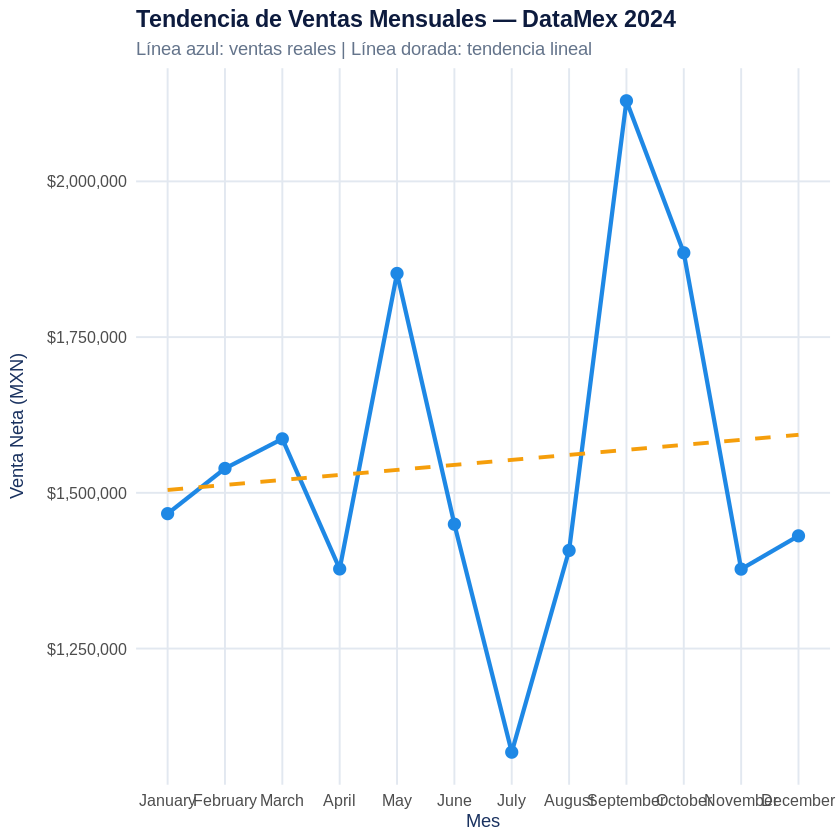

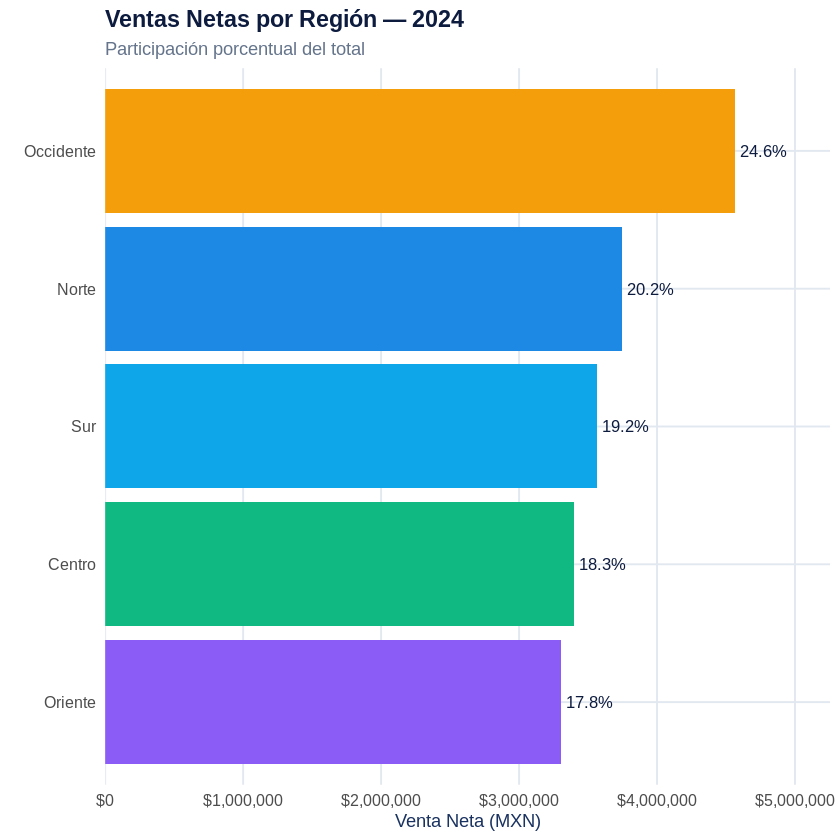

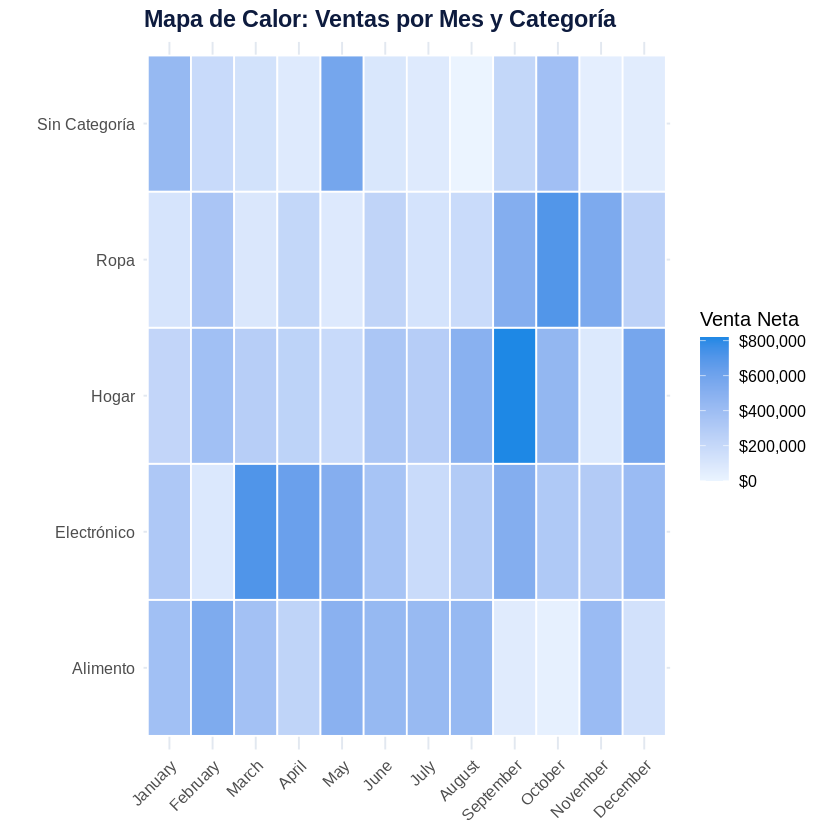

In [63]:
## ── SECCIÓN V: VISUALIZACIÓN CON GGPLOT2 ────────────────────────────
library(ggplot2)
library(scales)
library(dplyr)

## ── Tema corporativo DataMex ─────────────────────────────────────────
tema_datamex <- theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face="bold", color="#0D1B3E", size=14),
    plot.subtitle = element_text(color="#64748B", size=11),
    axis.title = element_text(color="#1A3260", size=11),
    panel.grid.major = element_line(color="#E2E8F0"),
    panel.grid.minor = element_blank()
  )

## ── Gráfico 1: Ventas mensuales (línea de tendencia) ─────────────────
g1 <- kpi_mensual %>%
  mutate(mes_n = row_number()) %>%
  ggplot(aes(x = mes_n, y = ventas)) +
  geom_line(color = "#1E88E5", linewidth = 1.2) +
  geom_point(color = "#1E88E5", size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "#F59E0B", linetype = 2) +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  scale_x_continuous(breaks = 1:nrow(kpi_mensual), labels = kpi_mensual$mes) +
  labs(
    title = "Tendencia de Ventas Mensuales — DataMex 2024",
    subtitle = "Línea azul: ventas reales | Línea dorada: tendencia lineal",
    x = "Mes", y = "Venta Neta (MXN)"
  ) + tema_datamex

print(g1)
ggsave("grafico1_tendencia_mensual.png", g1, width=10, height=5, dpi=150)

## ── Gráfico 2: Ventas por región (barras horizontales) ───────────────
g2 <- kpi_region %>%
  ggplot(aes(x = reorder(region, ventas), y = ventas, fill = region)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = paste0(round(participacion_pct,1), "%")),
            hjust = -0.1, size = 3.5, color = "#0D1B3E") +
  coord_flip() +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ","),
                     expand = expansion(mult = c(0, .15))) +
  scale_fill_manual(values = c("Norte"="#1E88E5", "Sur"="#0EA5E9",
                               "Centro"="#10B981", "Occidente"="#F59E0B",
                               "Oriente"="#8B5CF6")) +
  labs(title = "Ventas Netas por Región — 2024",
       subtitle = "Participación porcentual del total",
       x = NULL, y = "Venta Neta (MXN)") + tema_datamex

print(g2)
ggsave("grafico2_ventas_region.png", g2, width=8, height=5, dpi=150)

## ── Gráfico 3: Heatmap de ventas por mes y categoría ────────────────
g3 <- ventas_limpio %>%
  dplyr::group_by(mes, categoria) %>%
  dplyr::summarise(ventas = sum(venta_neta, na.rm=TRUE), .groups="drop") %>%
  ggplot(aes(x = mes, y = categoria, fill = ventas)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_gradient(low = "#EBF4FF", high = "#1E88E5",
                      labels = dollar_format(prefix="$", big.mark=",")) +
  labs(title = "Mapa de Calor: Ventas por Mes y Categoría",
       x = NULL, y = NULL, fill = "Venta Neta") + tema_datamex +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(g3)
ggsave("grafico3_heatmap.png", g3, width=10, height=5, dpi=150)

GRAFICO EXTRA

Warning message:
“Removed 53 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 53 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


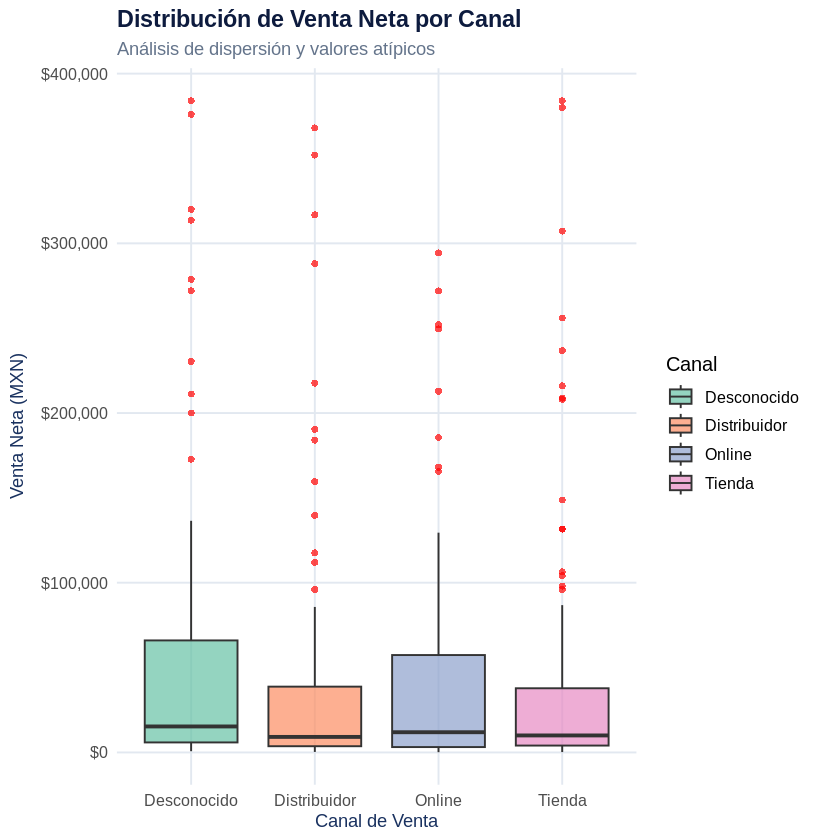

In [64]:
## ── Gráfico Extra: Distribución de Ventas por Canal (Boxplot) ───────

g4 <- ventas_limpio %>%
  ggplot(aes(x = canal_venta, y = venta_neta, fill = canal_venta)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red", outlier.shape = 16) +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = "Distribución de Venta Neta por Canal",
    subtitle = "Análisis de dispersión y valores atípicos",
    x = "Canal de Venta",
    y = "Venta Neta (MXN)",
    fill = "Canal"
  ) +
  tema_datamex

# Visualizar el gráfico
print(g4)

# Guardar el gráfico
ggsave("grafico4_boxplot_canales.png", g4, width=8, height=5, dpi=150)

MODELO PREDICTIVO EN R


=== MATRIZ DE CORRELACIÓN ===
                venta_neta cantidad descuento_pct precio_unitario
venta_neta           1.000    0.347        -0.029           0.822
cantidad             0.347    1.000        -0.023           0.021
descuento_pct       -0.029   -0.023         1.000           0.082
precio_unitario      0.822    0.021         0.082           1.000

=== MODELO SIMPLE ===

Call:
lm(formula = venta_neta ~ cantidad, data = datos_reg)

Residuals:
   Min     1Q Median     3Q    Max 
-82902 -40494 -14081   2057 300948 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -3351.0     7101.0  -0.472    0.637    
cantidad      1800.1      237.5   7.578 2.26e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 69080 on 420 degrees of freedom
Multiple R-squared:  0.1203,	Adjusted R-squared:  0.1182 
F-statistic: 57.43 on 1 and 420 DF,  p-value: 2.263e-13


=== MODELO MÚLTIPLE ===

Call:
lm(formula = venta_neta ~

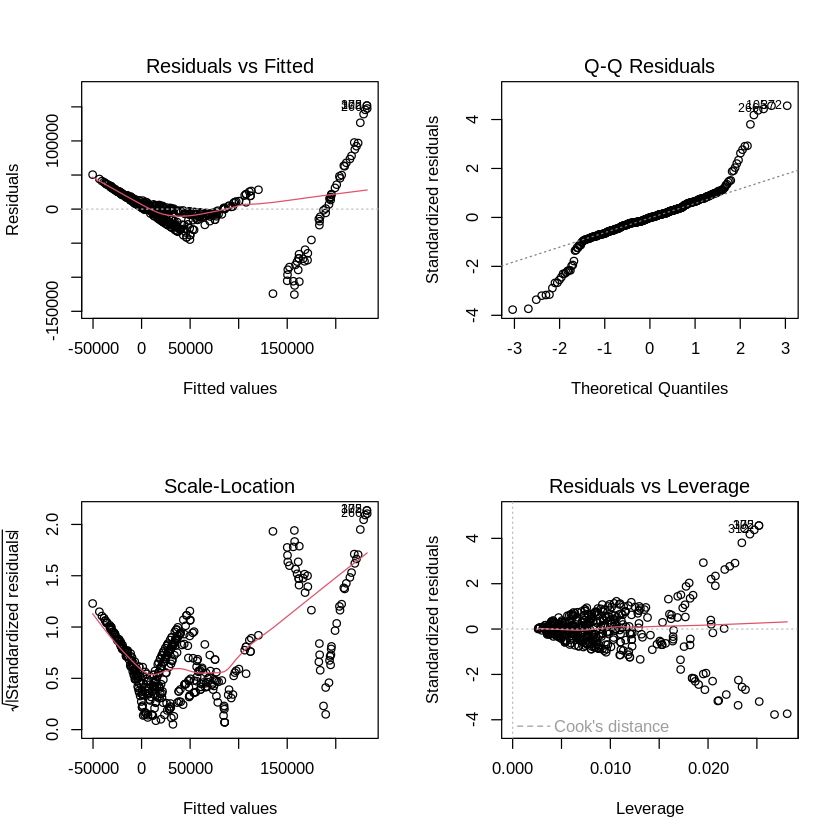

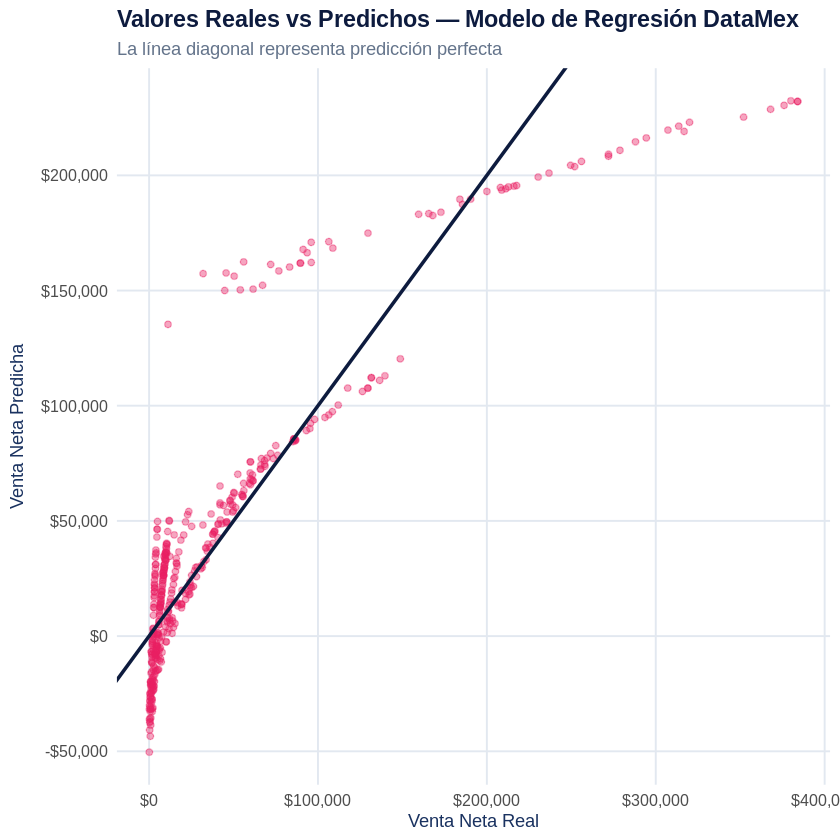

In [65]:
## ── SECCIÓN VI: ANÁLISIS PREDICTIVO — REGRESIÓN ─────────────────────
library(dplyr)
library(ggplot2)
library(scales)
library(tidyr)

## ── 6.1 Preparar dataset numérico ───────────────────────────────────
datos_reg <- ventas_limpio %>%
  dplyr::select(venta_neta, cantidad, descuento_pct, precio_unitario) %>%
  tidyr::drop_na()

## ── 6.2 Análisis de correlación ──────────────────────────────────────
cat("\n=== MATRIZ DE CORRELACIÓN ===\n")
print(round(cor(datos_reg), 3))

## ── 6.3 Regresión Lineal Simple: venta_neta ~ cantidad ───────────────
modelo_simple <- lm(venta_neta ~ cantidad, data = datos_reg)
cat("\n=== MODELO SIMPLE ===\n")
print(summary(modelo_simple))

## ── 6.4 Regresión Lineal Múltiple ────────────────────────────────────
modelo_multiple <- lm(venta_neta ~ cantidad + descuento_pct + precio_unitario,
                       data = datos_reg)
cat("\n=== MODELO MÚLTIPLE ===\n")
print(summary(modelo_multiple))

## ── 6.5 Métricas de evaluación ───────────────────────────────────────
predicciones <- predict(modelo_multiple, datos_reg)
residuos <- datos_reg$venta_neta - predicciones

metricas <- tibble(
  R_cuadrado = summary(modelo_multiple)$r.squared,
  R2_ajustado = summary(modelo_multiple)$adj.r.squared,
  RMSE = sqrt(mean(residuos^2)),
  MAE = mean(abs(residuos))
)
cat("\n=== MÉTRICAS DE EVALUACIÓN ===\n")
print(metricas)

## ── 6.6 Diagnóstico visual del modelo ────────────────────────────────
# Genera 4 gráficos de control para ver si el modelo es confiable
par(mfrow = c(2, 2))
plot(modelo_multiple)
par(mfrow = c(1, 1))

## ── 6.7 Predicción para nuevos datos ────────────────────────────────
nuevos_clientes <- tibble(
  cantidad = c(10, 25, 50, 100),
  descuento_pct = c(0, 10, 20, 30),
  precio_unitario = c(500, 1200, 3500, 8000)
)
nuevos_clientes$venta_predicha <- predict(modelo_multiple, nuevos_clientes)
cat("\n=== PRONÓSTICOS DE VENTA ===\n")
print(nuevos_clientes)

## ── 6.8 Gráfico de valores reales vs predichos ───────────────────────
g_prediccion <- tibble(real = datos_reg$venta_neta, predicho = predicciones) %>%
  ggplot(aes(x = real, y = predicho)) +
  geom_point(alpha = 0.4, color = "#E91E63", size = 1.5) +
  geom_abline(slope = 1, intercept = 0, color = "#0D1B3E", linewidth = 1) +
  scale_x_continuous(labels = dollar_format(prefix="$", big.mark=",")) +
  scale_y_continuous(labels = dollar_format(prefix="$", big.mark=",")) +
  labs(
    title = "Valores Reales vs Predichos — Modelo de Regresión DataMex",
    subtitle = "La línea diagonal representa predicción perfecta",
    x = "Venta Neta Real", y = "Venta Neta Predicha"
  ) + tema_datamex

print(g_prediccion)

PRONOSTICO DE ESENARIO ESPECIFICO

In [66]:
# R Script
# Código de predicción corregido:
nuevo_escenario <- tibble(
  cantidad = 75,
  descuento_pct = 15,
  precio_unitario = 2000
)

# Ejecutar predicción
resultado_prediccion <- predict(modelo_multiple, nuevo_escenario)
print(resultado_prediccion)

       1 
127575.3 


OBSERVACIONES: En lo particular me agrado la practica aunque estaba un poco dificil ya que una parte de los comandos estaban incorrectos y eran a base de algunos signos lo cual entorpercian la ejecucion del comando , de ahi en fuera la ejecucion de las actividades fueron esenciales y en lo personal me ayudan a comprender con mayor facilidad el porque de cada uno de los comandos de la practica.